In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
df = pd.read_csv('Dataset/movie_review.csv')
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
def clean_text(text):
    # Remove HTML Elements/Tags
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^A-Za-z\s+]', '', text)
    return text

In [4]:
df['review'] = df['review'].apply(clean_text)

In [6]:
X = df['review']
Y = df['sentiment']

In [7]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [9]:
ignore_words = {'I', 'not', 'do', 'like'}
custom_stop_words = list(set(ENGLISH_STOP_WORDS) - ignore_words)

In [10]:
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words = custom_stop_words,
    ngram_range = (1, 2)
)

In [11]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [15]:
model = MultinomialNB(alpha=0.1)

In [16]:
model.fit(X_train_tfidf, Y_train)
Y_pred = model.predict(X_test_tfidf)

In [18]:
cr = classification_report(Y_test, Y_pred)
cm = confusion_matrix(Y_test, Y_pred)

In [19]:
print(cr)

              precision    recall  f1-score   support

    negative       0.88      0.89      0.89      4961
    positive       0.89      0.88      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [20]:
print(cm)

[[4431  530]
 [ 610 4429]]


<Axes: >

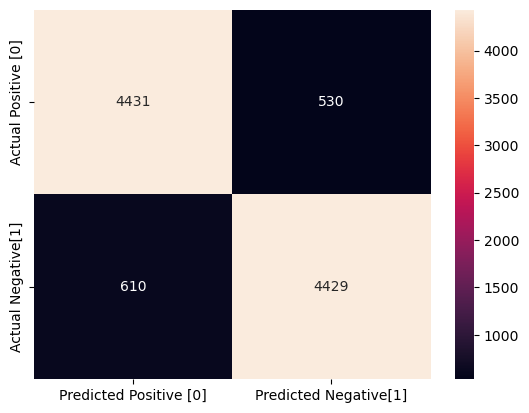

In [24]:
sns.heatmap(cm, annot=True, fmt='.0f', 
            xticklabels=['Predicted Positive [0]', 'Predicted Negative[1]'],
            yticklabels=['Actual Positive [0]', 'Actual Negative[1]'])

In [29]:
def predict_data(text):
    clean_data = clean_text(text)
    clean_data_tfidf = tfidf.transform([clean_data])
    data_pred = model.predict(clean_data_tfidf)[0]
    return data_pred

In [50]:
review = input('Enter your movie review here: ')
if predict_data(review) == 'negative':
    predict_data(review)
    print('\nNegative Review')
else:
    print('\nPositive Review')

Enter your movie review here:  If you like original gut wrenching laughter you will like this movie. If you are young or old then you will love this movie, hell even my mom liked it.<br /><br />Great Camp!!!



Positive Review
